In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import pandas as pd

#Discovery Questions; Do weight classes determine fighting style(using clustering), Does having significant reach determine strike accuracy(Using association technqiue)

#Load and clean data
#the csv borrowed courtesy of komaksym from UFC-DataLab
df = pd.read_csv('stats_reprocessed.csv', sep=';')
df.columns = df.columns.str.strip()
#I made a mistake here. I am keeping it as reference for myself
'''fight_data = df[['winner_name;', 'loser_name;', 'event_date;', 'method;', 'round;', 'time;', 'time_format;', 'bout_type;', 'event_name;', 'event_location;', 'winner_stance;', 'loser_stance;', 'winner;', 'delta_KD;', 'delta_sig_str_pct;', 'delta_total_str_pct;', 'delta_TD_pct;', 'delta_sub_att;', 'delta_rev;', 'delta_ctrl;', 'delta_sig_str_head_acc_pct;', 'delta_sig_str_body_acc_pct;', 'delta_sig_str_leg_acc_pct;', 'delta_sig_str_distance_acc_pct;-', 'delta_sig_str_clinch_acc_pct;', 'delta_sig_str_ground_acc_pct;', 'delta_sig_str_head_tar_pct;', 'delta_sig_str_body_tar_pct;', 'delta_sig_str_leg_tar_pct;', 'delta_sig_str_distance_pos_pct;', 'delta_sig_str_clinch_pos_pct;', 'delta_sig_str_ground_pos_pct;', 'delta_height;', 'delta_reach;', 'delta_slpm_cs;', 'delta_str_acc_cs;', 'delta_sapm_cs;', 'delta_str_def_cs;', 'delta_td_avg_cs;', 'delta_td_acc_cs;', 'delta_td_def_cs;', 'delta_sub_avg_cs;'
]]'''

#List of numerical features you want to analyze
columns_of_interest = ['delta_KD', 'delta_sig_str_pct', 'delta_ctrl']

#Generate summary statistics
#.describe() gives mean, std, min, 25%, 50% (median), 75%, and max
summary_stats = df[columns_of_interest].describe().loc[['mean', '50%', 'std', 'min', 'max']]

#Rename '50%' to 'median' for clarity
summary_stats.rename(index={'50%': 'median'}, inplace=True)

print(summary_stats)

        delta_KD  delta_sig_str_pct   delta_ctrl
mean    0.313338          10.822561   102.317850
median  0.000000          10.000000    38.000000
std     0.668334          20.767206   233.627312
min    -3.000000        -100.000000 -1164.000000
max     5.000000         100.000000  1301.000000


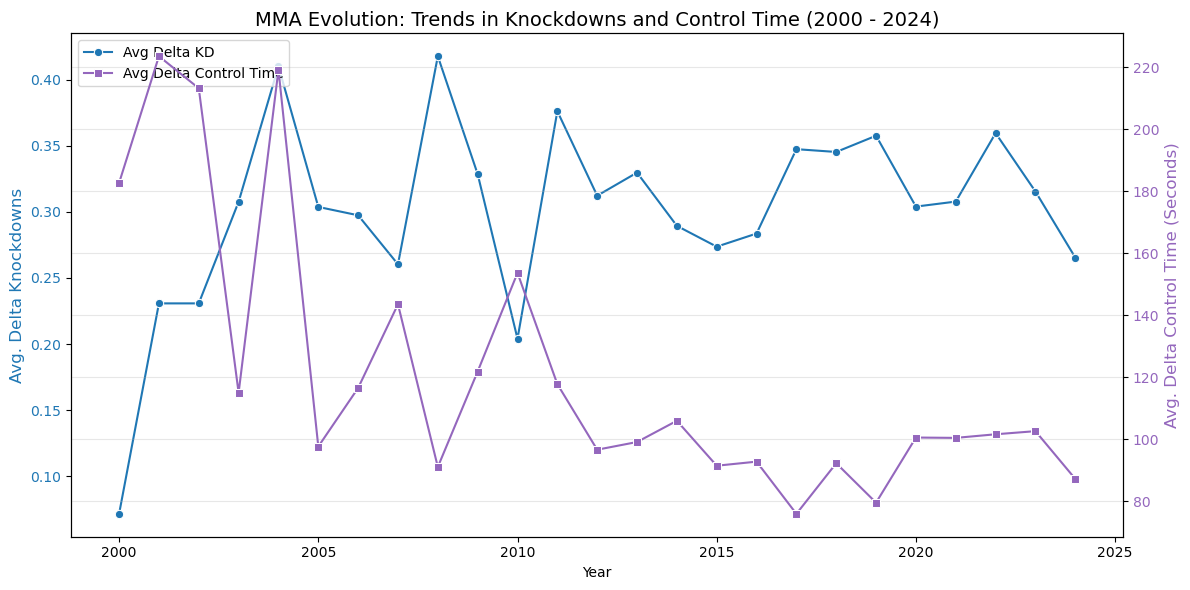

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import pandas as pd

#Load data
df = pd.read_csv('stats_reprocessed.csv', sep=';')
df.columns = df.columns.str.strip()

#Convert event_date to datetime and extract the Year
df['event_date'] = pd.to_datetime(df['event_date'], dayfirst=True)
df['year'] = df['event_date'].dt.year

#Calculate yearly averages
yearly_stats = df.groupby('year')[['delta_KD', 'delta_ctrl']].mean().reset_index()

#Create a Dual-Axis Line Chart
fig, ax1 = plt.subplots(figsize=(12, 6))

#Plot 1: Knockdowns (Left Y-Axis)
color1 = 'tab:blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('Avg. Delta Knockdowns', color=color1, fontsize=12)
# Set legend=False so Seaborn doesn't create its own legend on this axis
sns.lineplot(data=yearly_stats, x='year', y='delta_KD', ax=ax1, color=color1, 
             marker='o', label='Avg Delta KD', legend=False)
ax1.tick_params(axis='y', labelcolor=color1)

#Plot 2: Control Time (Right Y-Axis)
ax2 = ax1.twinx()
color2 = 'tab:purple'
ax2.set_ylabel('Avg. Delta Control Time (Seconds)', color=color2, fontsize=12)
#Set legend=False here as well
sns.lineplot(data=yearly_stats, x='year', y='delta_ctrl', ax=ax2, color=color2, 
             marker='s', label='Avg Delta Control Time', legend=False)
ax2.tick_params(axis='y', labelcolor=color2)

handler1, label1 = ax1.get_legend_handles_labels()
handler2, label2 = ax2.get_legend_handles_labels()

ax1.legend(handler1 + handler2, label1 + label2, loc='upper left', frameon=True)

plt.title('MMA Evolution: Trends in Knockdowns and Control Time (2000 - 2024)', fontsize=14)
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

Probably might need to prune some data so Knockdowns and Control times line up better...

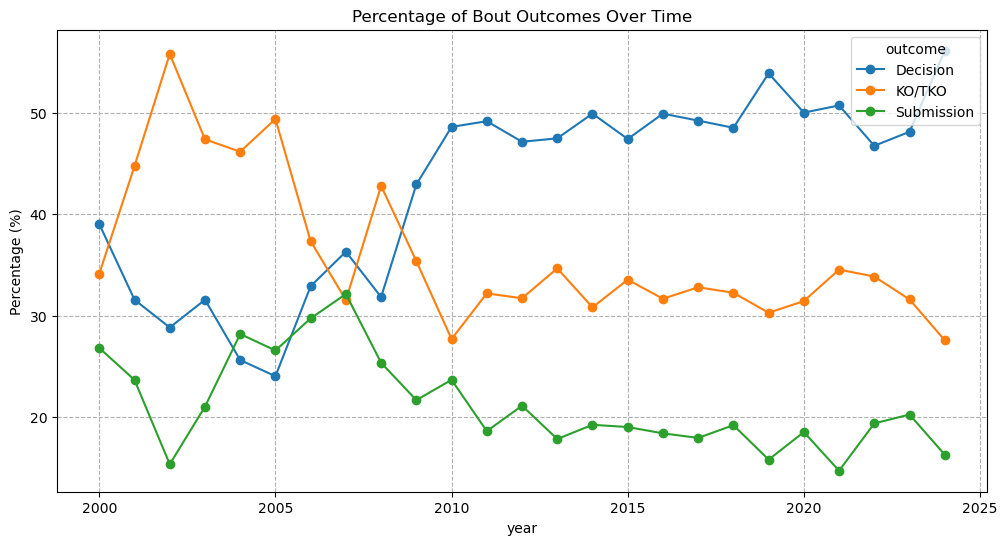

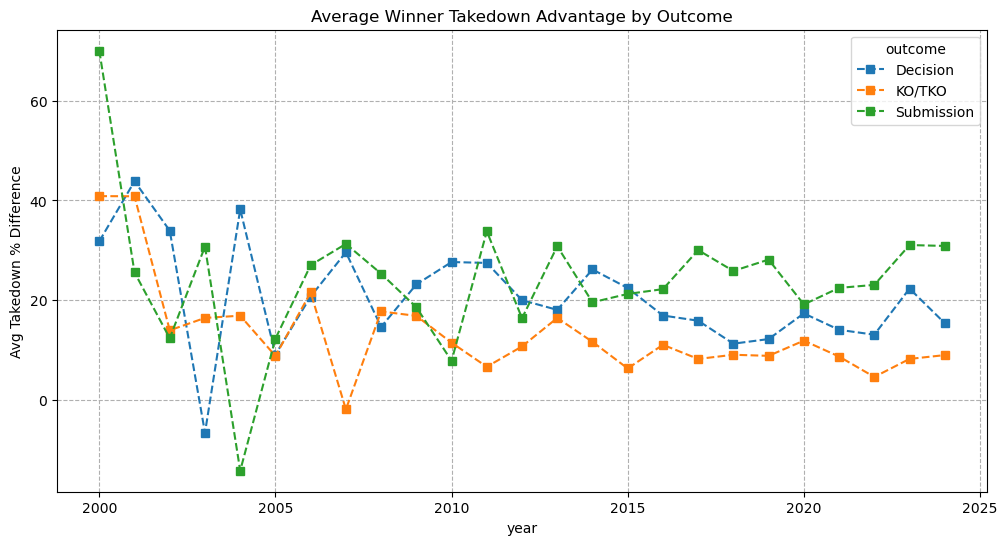

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import pandas as pd

#Load and preprocess
df = pd.read_csv('stats_reprocessed.csv', sep=';')
df['event_date'] = pd.to_datetime(df['event_date'], format='%d/%m/%Y', errors='coerce')
df['year'] = df['event_date'].dt.year

#Categorize outcomes
df['outcome'] = df['method'].apply(lambda x: 'Decision' if 'Decision' in x 
                                  else ('KO/TKO' if 'KO/TKO' in x or 'TKO' in x 
                                  else ('Submission' if 'Submission' in x else 'Other')))

#Filter for the main three categories and group by year
df_main = df[df['outcome'].isin(['Decision', 'KO/TKO', 'Submission'])]
outcome_counts = df_main.groupby(['year', 'outcome']).size().unstack(fill_value=0)

#Plotting Percentage of Outcomes Over Time
outcome_pct = outcome_counts.div(outcome_counts.sum(axis=1), axis=0) * 100
plt.figure(figsize=(12, 6))
outcome_pct.plot(kind='line', marker='o', ax=plt.gca())
plt.title('Percentage of Bout Outcomes Over Time')
plt.ylabel('Percentage (%)')
plt.grid(True, linestyle='--')

#Plotting Average Takedown Advantage Trend
td_trend = df_main.groupby(['year', 'outcome'])['delta_TD_pct'].mean().unstack()
plt.figure(figsize=(12, 6))
td_trend.plot(kind='line', marker='s', linestyle='--', ax=plt.gca())
plt.title('Average Winner Takedown Advantage by Outcome')
plt.ylabel('Avg Takedown % Difference')
plt.grid(True, linestyle='--')

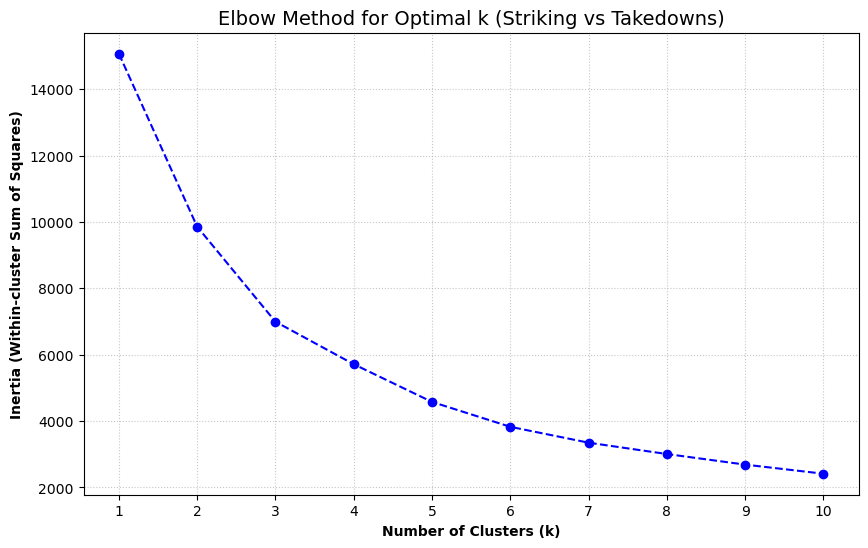

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import pandas as pd

#Discovery Questions; Do weight classes determine fighting style(using clustering), Does having significant reach determine strike accuracy(Using association technqiue)

#Load and clean data
#the csv borrowed courtesy of komaksym from UFC-DataLab
df = pd.read_csv('stats_reprocessed.csv', sep=';')
df.columns = df.columns.str.strip()
#I made a mistake here. I am keeping it as reference for myself
'''fight_data = df[['winner_name;', 'loser_name;', 'event_date;', 'method;', 'round;', 'time;', 'time_format;', 'bout_type;', 'event_name;', 'event_location;', 'winner_stance;', 'loser_stance;', 'winner;', 'delta_KD;', 'delta_sig_str_pct;', 'delta_total_str_pct;', 'delta_TD_pct;', 'delta_sub_att;', 'delta_rev;', 'delta_ctrl;', 'delta_sig_str_head_acc_pct;', 'delta_sig_str_body_acc_pct;', 'delta_sig_str_leg_acc_pct;', 'delta_sig_str_distance_acc_pct;-', 'delta_sig_str_clinch_acc_pct;', 'delta_sig_str_ground_acc_pct;', 'delta_sig_str_head_tar_pct;', 'delta_sig_str_body_tar_pct;', 'delta_sig_str_leg_tar_pct;', 'delta_sig_str_distance_pos_pct;', 'delta_sig_str_clinch_pos_pct;', 'delta_sig_str_ground_pos_pct;', 'delta_height;', 'delta_reach;', 'delta_slpm_cs;', 'delta_str_acc_cs;', 'delta_sapm_cs;', 'delta_str_def_cs;', 'delta_td_avg_cs;', 'delta_td_acc_cs;', 'delta_td_def_cs;', 'delta_sub_avg_cs;'
]]'''


#Filter relevant features and drop NaNs
features = ['delta_sig_str_pct', 'delta_TD_pct']
fight_data = df[features].dropna()

#Preprocess the data
scaler = StandardScaler()
scaled_fights = scaler.fit_transform(fight_data)

#Run KMeans for a range of k values
inertia = []
K_range = range(1, 11)

for k in K_range:
    #Use n_init=10 to suppress warnings and ensure stability
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_fights)
    inertia.append(kmeans.inertia_)

#Plotting the Elbow Method result where the ideal is k = 4
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)', fontweight='bold')
plt.ylabel('Inertia (Within-cluster Sum of Squares)', fontweight='bold')
plt.title('Elbow Method for Optimal k (Striking vs Takedowns)', fontsize=14)
plt.xticks(K_range)
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

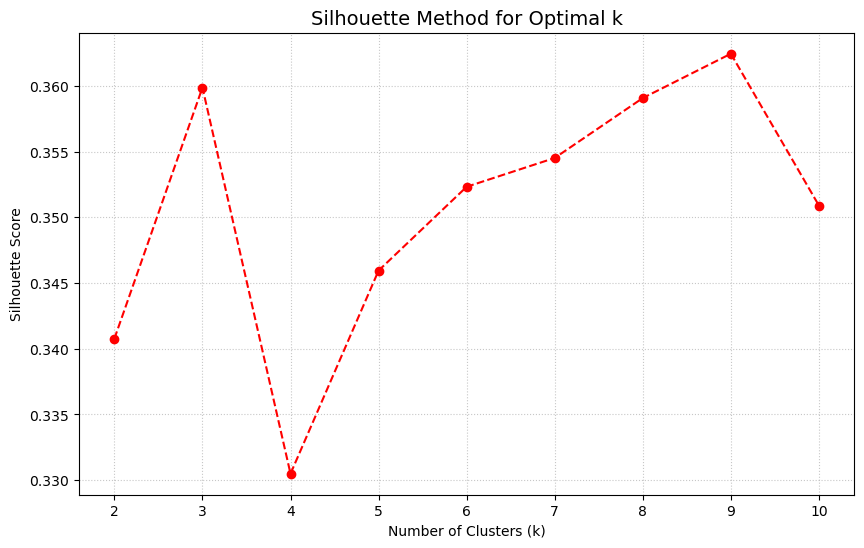

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import pandas as pd
from sklearn.metrics import silhouette_score

#Range of k to test (Silhouette is not defined for k=1)
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_fights)
    score = silhouette_score(scaled_fights, labels)
    silhouette_scores.append(score)

#Plotting
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='o', linestyle='--', color='r')
plt.title('Silhouette Method for Optimal k', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

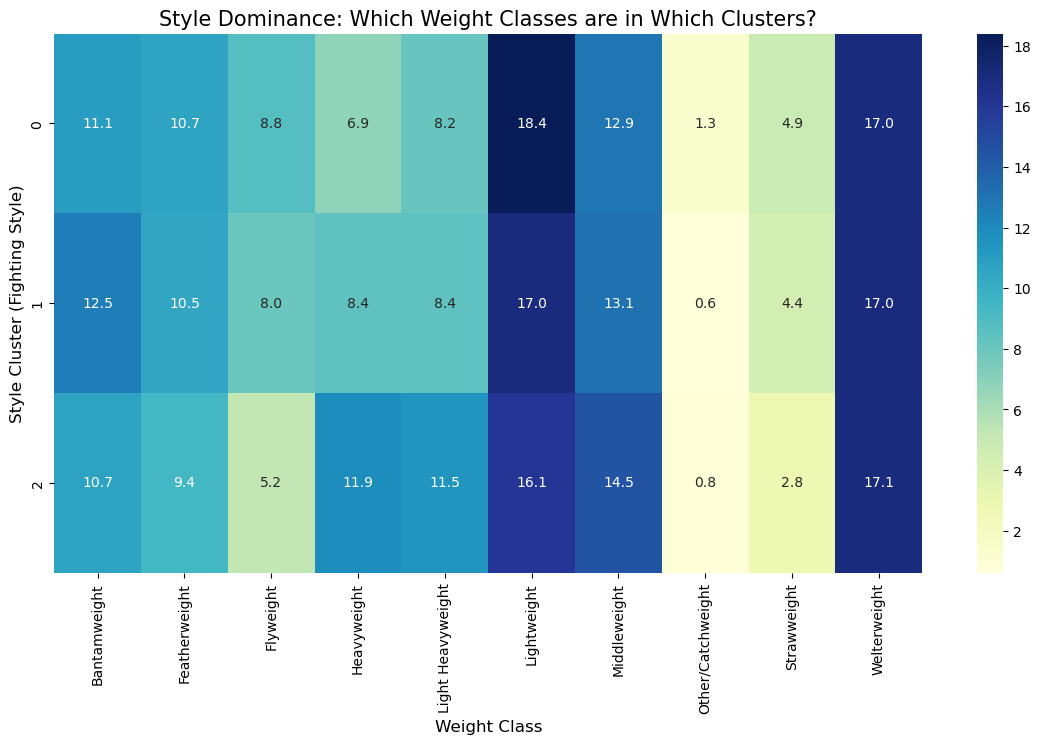

In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import pandas as pd

#Load Data
#the csv borrowed courtesy of komaksym from UFC-DataLab
df = pd.read_csv('stats_reprocessed.csv', sep=';')
df.columns = df.columns.str.strip()

features = ['delta_sig_str_pct', 'delta_TD_pct']
df_clean = df.dropna(subset=features).copy()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean[features])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(scaled_data)

#Simplify Bout Types to Weight Classes
def simplify_bout(bout):
    bout = str(bout).lower()
    if 'light heavyweight' in bout: return 'Light Heavyweight'
    if 'heavyweight' in bout: return 'Heavyweight'
    if 'middleweight' in bout: return 'Middleweight'
    if 'welterweight' in bout: return 'Welterweight'
    if 'lightweight' in bout: return 'Lightweight'
    if 'featherweight' in bout: return 'Featherweight'
    if 'bantamweight' in bout: return 'Bantamweight'
    if 'flyweight' in bout: return 'Flyweight'
    if 'strawweight' in bout: return 'Strawweight'
    return 'Other/Catchweight'

df_clean['weight_class'] = df_clean['bout_type'].apply(simplify_bout)

#Create a Composition Matrix (normalize by 'index' to see % of cluster)
cluster_composition = pd.crosstab(df_clean['cluster'], df_clean['weight_class'], normalize='index') * 100

#Plot Heatmap
plt.figure(figsize=(14, 7))
sns.heatmap(cluster_composition, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Style Dominance: Which Weight Classes are in Which Clusters?', fontsize=15)
plt.ylabel('Style Cluster (Fighting Style)', fontsize=12)
plt.xlabel('Weight Class', fontsize=12)
plt.show()

#0 is defensive/balanced styles, 1 is grappling focused, 2 is clinical strikes, 3 is heavy aggression in fights

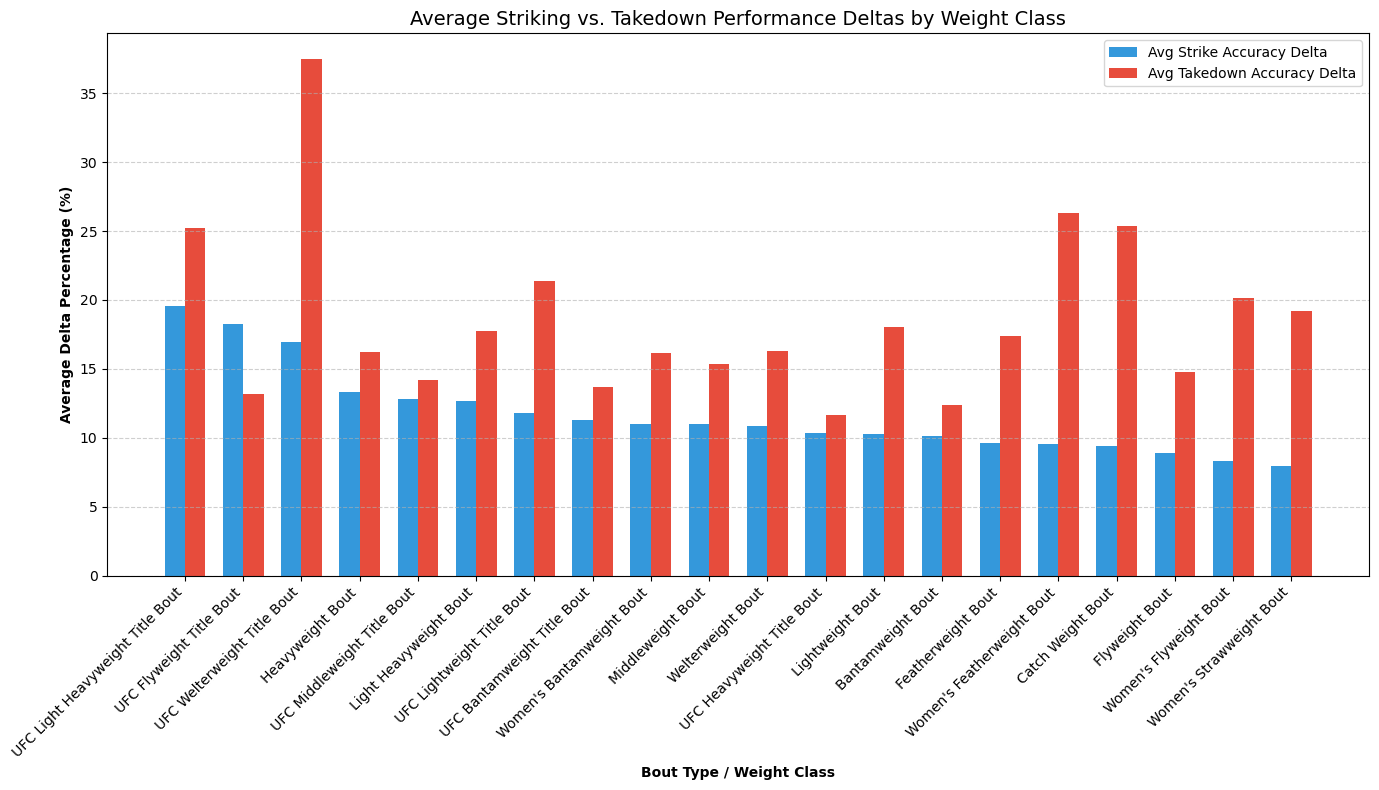

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import pandas as pd

#Load data
#the csv borrowed courtesy of komaksym from UFC-DataLab
df = pd.read_csv('stats_reprocessed.csv', sep=';')
df.columns = df.columns.str.strip()

#Group by bout_type and calculate average deltas
#filter for types with at least 20 fights to avoid outliers from rare bout types
bout_counts = df['bout_type'].value_counts()
common_bouts = bout_counts[bout_counts > 20].index
avg_stats = df[df['bout_type'].isin(common_bouts)].groupby('bout_type')[['delta_sig_str_pct', 'delta_TD_pct']].mean()

#Sort by striking delta for better visualization flow
avg_stats = avg_stats.sort_values(by='delta_sig_str_pct', ascending=False)

#Create the Bar Graph
plt.figure(figsize=(14, 8))
x = np.arange(len(avg_stats.index))
width = 0.35

plt.bar(x - width/2, avg_stats['delta_sig_str_pct'], width, label='Avg Strike Accuracy Delta', color='#3498db')
plt.bar(x + width/2, avg_stats['delta_TD_pct'], width, label='Avg Takedown Accuracy Delta', color='#e74c3c')

#Formatting the plot
plt.xlabel('Bout Type / Weight Class', fontweight='bold')
plt.ylabel('Average Delta Percentage (%)', fontweight='bold')
plt.title('Average Striking vs. Takedown Performance Deltas by Weight Class', fontsize=14)
plt.xticks(x, avg_stats.index, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#